# Código Auxiliar para a Segunda Avaliação.

In [ ]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from scipy.datasets import face
from itertools import islice

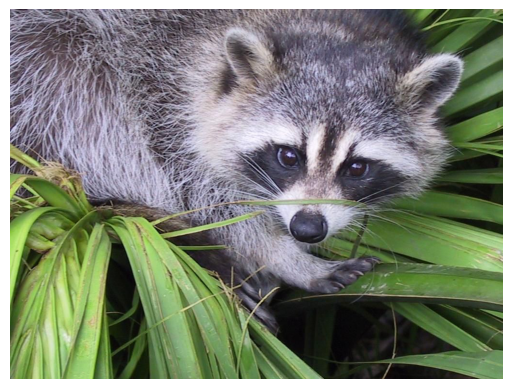

In [43]:
AUTORES = ['Abner Blota Rodrigues', 'Diogo Vieira dos Santos']

guaxinim = face()
plt.imshow(guaxinim)
plt.axis('off') 
plt.show()

As funções definidas abaixo, devem ser usada para acessar o banco de dados `bilheteria.db` e retornar os dados necessários para a resolução dos exercícios.


In [3]:
def carrega_tabela(database, tabela):
    '''
    Carrega uma tabela de um banco de dados 
    SQLite em um DataFrame do Pandas.
    Parâmetros:
    database: str - Caminho para o arquivo do banco de dados SQLite.
    tabela: str - Nome da tabela a ser carregada.
    '''
    with sqlite3.connect(database) as conn:
        query = f"SELECT * FROM {tabela}"
        df = pd.read_sql_query(query, conn)
    return df

In [4]:
def lista_tabelas(db_filename):
    '''
    Lista todas as tabelas em um banco de dados SQLite.
    Parâmetros:
    db_filename: str - Caminho para o arquivo do banco de dados SQLite.
    Retorna:
    DataFrame com os nomes das tabelas e suas contagens de linhas.
    '''
    # Connect to the SQLite database
    # conn = sqlite3.connect(db_filename)
    with sqlite3.connect(db_filename) as conn:
        cursor = conn.cursor()
        cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
        tables = cursor.fetchall()

        table_row_counts = []
        for table in tables:
            table_name = table[0]
            query = f"SELECT COUNT(*) FROM {table_name};"
            cursor.execute(query)
            row_count = cursor.fetchone()[0]
            table_row_counts.append({"Table": table_name, "Row_Count": row_count})

        return pd.DataFrame(table_row_counts)

## Exemplos de uso das funções

In [5]:
lista_tabelas('bilheteria.db')

,Table,Row_Count
0,distribuidora,72
1,filme,515
2,grupo_exibidor,64
3,exibidor,180
4,complexo,683
5,sala,3231
6,sessao,1748363


In [6]:
data_frame = carrega_tabela('bilheteria.db','sessao')
display(data_frame)

,id,filme_id,sala_id,publico,data_exibicao
0,1,253,5004897,8,01/01/2023
1,2,253,5001565,15,01/01/2023
2,3,253,5001566,14,01/01/2023
3,4,253,5003464,23,01/01/2023
4,5,253,5001137,37,01/01/2023
...,...,...,...,...,...
1748358,1748359,405,5000331,5,31/12/2023
1748359,1748360,405,5000333,11,31/12/2023
1748360,1748361,405,5003637,32,31/12/2023
1748361,1748362,157,5001209,124,31/12/2023


In [7]:
sessao = carrega_tabela('bilheteria.db', 'sessao')
sessao.data_exibicao = pd.to_datetime(sessao.data_exibicao, format='%d/%m/%Y')
sessao


,id,filme_id,sala_id,publico,data_exibicao
0,1,253,5004897,8,2023-01-01
1,2,253,5001565,15,2023-01-01
2,3,253,5001566,14,2023-01-01
3,4,253,5003464,23,2023-01-01
4,5,253,5001137,37,2023-01-01
...,...,...,...,...,...
1748358,1748359,405,5000331,5,2023-12-31
1748359,1748360,405,5000333,11,2023-12-31
1748360,1748361,405,5003637,32,2023-12-31
1748361,1748362,157,5001209,124,2023-12-31


## PARTE 1: Análise exploratória dos dados

In [42]:
# Questão 0: Importando as tabela

bd_filmes = carrega_tabela('bilheteria.db','filme')
bd_sessao = carrega_tabela('bilheteria.db','sessao')
bd_complexo = carrega_tabela('bilheteria.db','complexo')


In [ ]:
# Questão 1: Qual o total de bilheteria de todos os filmes, ou seja, o público que foi aos filmes listados?

bilheteria_filme = [0 for i in range(0,515)]
indice_filmes = []
def bilheteria():

    for i in range(0,515):
        indice_filmes.append(bd_filmes.loc[i,'titulo_original'])

    for i in range(0,1748363):
        publico = bd_sessao.loc[i,'publico']
        bilheteria_filme[bd_sessao.loc[i,'filme_id']-1] += publico

    dados = {
        "Nome_filme" : indice_filmes,
        "Bilheteria" : bilheteria_filme
    }

    df_bilheteria = pd.DataFrame(dados)
    total_bilheteria = sum(bilheteria_filme)
    return df_bilheteria, total_bilheteria

df_bilheteria, total_bilheteria = bilheteria()
print(total_bilheteria)
display(df_bilheteria)

In [ ]:
# Questão 2: Qual o filme de maior bilheteria em 2023, por país de origem?


def bilheteria_paises():
    bilheteria_int = [int(x) for x in bilheteria_filme]
    dic_bilheteria = dict(zip(indice_filmes,bilheteria_int))
    paises = []
    filmes = []
    for i in range(0,515):
        if bd_filmes.loc[i,"pais_origem"] not in paises:
            pais = bd_filmes.loc[i,"pais_origem"]
            filmes_pais = bd_filmes[bd_filmes['pais_origem'] == pais]
            filme_atual = filmes_pais.iloc[0]['titulo_original']
            for i in filmes_pais['titulo_original']:
                if dic_bilheteria[filme_atual]<dic_bilheteria[i]:
                    filme_atual = i
            filmes.append(filme_atual)
            paises.append(pais)

    dados_2 = {
        'Países' : paises,
        'Filmes' : filmes
    }
    df_bilheteria_paises = pd.DataFrame(dados_2)
    return df_bilheteria_paises

df_bilheteria_paises = bilheteria_paises()
display(df_bilheteria_paises)

,Países,Filmes
0,BRASIL,NOSSO SONHO
1,PORTUGAL,A ÚLTIMA FESTA
2,ARGENTINA,BEM-VINDA VIOLETA
3,FRANÇA,THE THREE MUSKETEERS: D’ARTAGNAN
4,CANADÁ,PAW PATROL: THE MIGHTY MOVIE
5,ESTADOS UNIDOS,BARBIE
6,REINO UNIDO,GOLDA
7,INGLATERRA,NAPOLEON
8,CORÉIA DO SUL,DECISION TO LEAVE
9,PERU,AINBO - THE SPIRIT OF THE AMAZON


In [ ]:
def questao_3(nome="bilheteria.db"):
    ### Carregando os dados

    db_sessao = carrega_tabela(nome, "sessao")
    df_sessao = pd.DataFrame(db_sessao)

    db_filme = carrega_tabela(nome, "filme")
    df_filme = pd.DataFrame(db_filme)

    db_sala = carrega_tabela(nome, "sala")
    df_sala = pd.DataFrame(db_sala)

    db_complexo = carrega_tabela(nome, "complexo")
    df_complexo = pd.DataFrame(db_complexo)

    ### Criando uma tabela com vários merges

    df_me = (
        df_sessao
        .merge(df_sala[['id', 'from_complexo']], 
            left_on='sala_id', right_on='id', how='left', suffixes=('', '_id_temp'))
        .merge(df_complexo[['id', 'municipio']], 
            left_on='from_complexo', right_on='id', how='left')
        .merge(df_filme[['id', 'titulo_original']],
                left_on='filme_id', right_on='id', how='left')
    )



# df_ri['data_exibicao'] = pd.to_datetime(df_ri['data_exibicao'], format='mixed')
# display(df_ri)
# df_2023 = df_ri[df_ri['data_exibicao'].dt.year == 2023]


    ### Agrupando soma

    df_agrupado = df_me.groupby(['municipio']).agg(
        BILHETERIA=('publico', 'sum')
    ).reset_index()

    df_resposta = df_agrupado

    df_resposta.sort_values('BILHETERIA', ascending=False, inplace=True)

    df_resposta.rename(columns={"municipio": "CIDADE"}, inplace=True)
    df_resposta.index = range(1, len(df_resposta) + 1)
    return df_resposta.head(100)

questao_3("bilheteria.db")

,CIDADE,BILHETERIA
1,SÃO PAULO,13310470
2,RIO DE JANEIRO,8496306
3,BRASÍLIA,3272437
4,BELO HORIZONTE,3009414
5,CURITIBA,2965114
...,...,...
96,ARAÇATUBA,247992
97,VITÓRIA DA CONQUISTA,246490
98,PONTA GROSSA,241142
99,LAURO DE FREITAS,240784


In [88]:
def questao_4(nome):
    
    ### Carregando os dados

    db_sessao = carrega_tabela(nome, "sessao")
    df_sessao = pd.DataFrame(db_sessao)

    db_filme = carrega_tabela(nome, "filme")
    df_filme = pd.DataFrame(db_filme)

    db_sala = carrega_tabela(nome, "sala")
    df_sala = pd.DataFrame(db_sala)

    db_complexo = carrega_tabela(nome, "complexo")
    df_complexo = pd.DataFrame(db_complexo)

    ### Criando uma tabela com vários merges

    df_me = (
        df_sessao
        .merge(df_sala[['id', 'from_complexo']], 
            left_on='sala_id', right_on='id', how='left', suffixes=('', '_id_temp'))
        .merge(df_complexo[['id', 'municipio']], 
            left_on='from_complexo', right_on='id', how='left')
        .merge(df_filme[['id', 'titulo_original']],
                left_on='filme_id', right_on='id', how='left')
    )

    df_agrupado = df_me.groupby(['filme_id', 'municipio']).agg(
        bilheteria=('publico', 'sum')
    )

    df_maior = (
        df_agrupado
        .sort_values('bilheteria', ascending=False)
        .reset_index()
        .drop_duplicates(subset=['municipio'])
    )

    df_resposta = (
        df_maior
        .merge(df_filme[["id", "titulo_original"]], left_on='filme_id', right_on="id", how="left")
    )

    df_resposta.rename(columns={"titulo_original": "FILME", "bilheteria": "BILHETERIA", "municipio": "CIDADE"}, inplace=True)
    df_resposta.index = range(1, len(df_resposta) + 1)
    return df_resposta[["CIDADE", "FILME", "BILHETERIA"]]

questao_4("bilheteria.db")

,CIDADE,FILME,BILHETERIA
1,SÃO PAULO,BARBIE,1201206
2,RIO DE JANEIRO,BARBIE,719539
3,BRASÍLIA,BARBIE,289033
4,BELO HORIZONTE,BARBIE,283911
5,CURITIBA,BARBIE,269314
...,...,...,...
341,CAMPOS NOVOS,FAST X,654
342,MOGI-GUACU,THE EXPENDABLES 4,601
343,CÓRREGO FUNDO,FRANCO NO TREM DO MEDO,53
344,PAINS,FRANCO NO TREM DO MEDO,51


In [90]:

def questao_5(nome):

       ### Carregando os dados
       db_sessao = carrega_tabela(nome, "sessao")
       df_sessao = pd.DataFrame(db_sessao)

       db_filme = carrega_tabela(nome, "filme")
       df_filme = pd.DataFrame(db_filme)

       db_sala = carrega_tabela(nome, "sala")
       df_sala = pd.DataFrame(db_sala)

       db_complexo = carrega_tabela(nome, "complexo")
       df_complexo = pd.DataFrame(db_complexo)
 
       ### Criando uma tabela com vários merges

       df_me = (
              df_sessao
              .merge(df_sala[['id', 'from_complexo']], 
                     left_on='sala_id', right_on='id', how='left', suffixes=('', '_id_temp'))
              .merge(df_complexo[['id', 'municipio']], 
                     left_on='from_complexo', right_on='id', how='left')
              .merge(df_filme[['id', 'titulo_original', 'pais_origem']],
                     left_on='filme_id', right_on='id', how='left')
       )

       ### Criando um dataframe com os dados interessantes

       df_bilheterias = pd.DataFrame({
              'BILHETERIA_BR':df_me[df_me["pais_origem"].eq("BRASIL")].groupby('municipio')["publico"].sum(),
              'BILHETERIA_ESTRANGEIRA':df_me[~df_me["pais_origem"].eq("BRASIL")].groupby('municipio')["publico"].sum()
       }).reset_index().fillna(0).sort_values("BILHETERIA_BR", ascending=False)

       df_bilheterias.rename(columns={"municipio": "CIDADE"}, inplace=True)

       return df_bilheterias

questao_5("bilheteria.db")

,CIDADE,BILHETERIA_BR,BILHETERIA_ESTRANGEIRA
263,RIO DE JANEIRO,546789.0,7949517.0
309,SÃO PAULO,403251.0,12907219.0
268,SALVADOR,166624.0,2304396.0
40,BELO HORIZONTE,98746.0,2910668.0
256,RECIFE,84134.0,2248439.0
...,...,...,...
148,ITAPEVA,0.0,19472.0
181,LINS,0.0,18654.0
193,MARATAÍZES,0.0,10691.0
68,CANOINHAS,0.0,19082.0


## PARTE 2: Análise estatística dos dados